# 🚢 Project 3: Titanic Survival Prediction

This is one of the most important beginner Machine Learning projects because it introduces real-world messy data.

In the Iris project:

- ✅ Clean dataset
- ✅ No missing values
- ✅ Easy classification

In Titanic:
- ✅ Missing values
- ✅ Categorical data
- ✅ Data cleaning
- ✅ Feature engineering
- ✅ Encoding
- ✅ Classification

This project teaches skills used in actual ML jobs.


# 🎯 Problem Definition

Imagine you are on the Titanic.

Given:

| Feature         | Example |
| --------------- | ------- |
| Age             | 25      |
| Gender          | Male    |
| Passenger Class | 3       |
| Fare            | 15.5    |


### Input Features (X)

Examples:

- Passenger Class (Pclass)
- Sex
- Age
- Fare
- SibSp
- Parch  

### Target (y)
Survived

Values:

- 0 = Did Not Survive
- 1 = Survived

# Type of Machine Learning

Output:

1. Survived
2. Not Survived

Only two classes.

Therefore:

- ✅ Supervised Learning
- ✅ Binary Classification

# 📂 Step 1: Get the Dataset

The most famous Titanic dataset is available on:

Kaggle Titanic Competition

# Step 2: Install Libraries

`pip install numpy pandas matplotlib seaborn scikit-learn joblib`

# Step 3: Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Step 4: Load Dataset

In [3]:
df = pd.read_csv("Titanic-Dataset.csv")

# Step 5: View Dataset

In [4]:
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


# Step 6: Understand Dataset Shape

In [5]:
print(df.shape)

(891, 12)


# Step 7: Dataset Information

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [ ]:
print(df.describe())

This step is extremely important.

You will discover:

- Age has missing values
- Cabin has many missing values
- Embarked has few missing values

# 🔥 Important Concept: Missing Values

Real-world data is messy.

Example:

| Name  | Age |
| ----- | --- |
| John  | 25  |
| Alice | NaN |
| Bob   | 30  |

Machine learning models cannot learn from empty values.

We must handle them.

# Step 8: Check Missing Values

In [7]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


# Step 10: Handle Missing Age Values

Age is important.

Instead of deleting rows:

Use median age.

In [8]:
df["Age"] = df["Age"].fillna(
    df["Age"].median()
)

Why median?

Because age may contain outliers.

# Step 11: Handle Embarked

In [14]:
df["Embarked"] = df["Embarked"].fillna(
    df["Embarked"].mode()[0]
)

# Step 12: Drop Cabin Column

Cabin contains too many missing values.

In [15]:
df.drop(
    "Cabin",
    axis=1,
    inplace=True
)

### Verify Again


In [16]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


Everything should be 0.

# 🧠 Important Concept: Categorical Data

Current values:

- Male
- Female

Machine learning models understand:

- 0
- 1

not words.

We must encode them.

# Step 13: Encode Gender
 Result:

- female = 0
- male = 1

In [20]:
encoder = LabelEncoder()

df["Sex"] = encoder.fit_transform(
    df["Sex"]
)

# Step 14: Encode Embarked
Example:

- C = 0
- Q = 1
- S = 2

In [21]:
df["Embarked"] = encoder.fit_transform(
    df["Embarked"]
)

# Step 15: Drop Unnecessary Columns

These columns do not help much:

In [ ]:
df.drop(
    [
        "PassengerId",
        "Name",
        "Ticket"
    ],
    axis=1,
    inplace=True
)

In [26]:

print(df.head())

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    1  22.0      1      0   7.2500         2
1         1       1    0  38.0      1      0  71.2833         0
2         1       3    0  26.0      0      0   7.9250         2
3         1       1    0  35.0      1      0  53.1000         2
4         0       3    1  35.0      0      0   8.0500         2


In [27]:
print(df.shape)

(891, 8)


# Step 16: Correlation Analysis

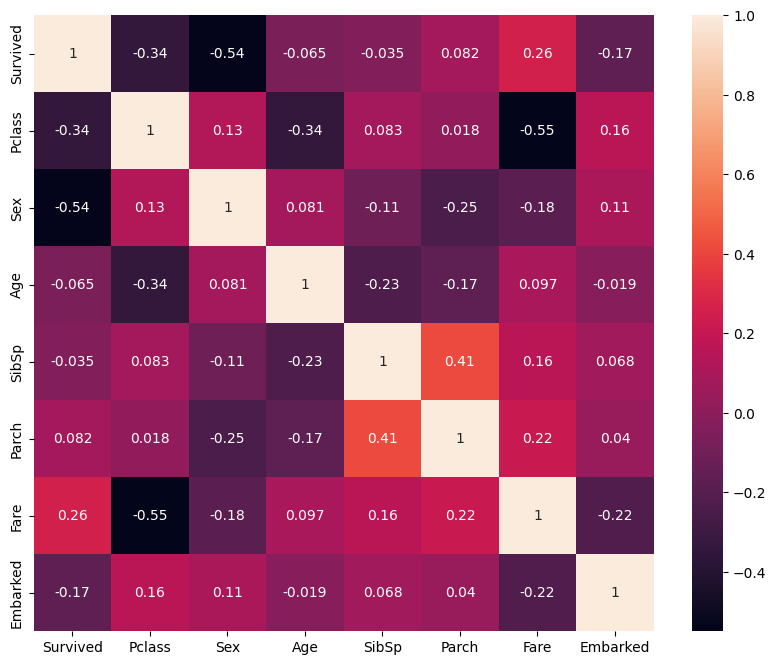

In [28]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True
)

plt.show()

# Step 17: Define Features (X)

In [29]:
X = df.drop(
    "Survived",
    axis=1
)

# Step 18: Define Target (y)

In [30]:
y = df["Survived"]

# Step 19: Train-Test Spli

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Step 20: Create Model

We'll use Decision Tree.

Why?

Easy to understand.

Example:

- Is Female?
-     ↓
- Yes → Survive
- No
-     ↓
- Age < 10 ?
-     ↓
- Yes → Survive
- No → Not Survive

# Step 21: Train Model

In [32]:
model = DecisionTreeClassifier(
    random_state=42
)

model.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(random_state=42)

# Step 22: Make Predictions

In [33]:
predictions = model.predict(
    X_test
)

# Step 23: Calculate Accuracy

In [35]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.7821229050279329


# Step 24: Confusion Matrix

In [36]:
cm = confusion_matrix(
    y_test,
    predictions
)

print(cm)

[[83 22]
 [17 57]]


# Step 25: Visualize Confusion Matrix

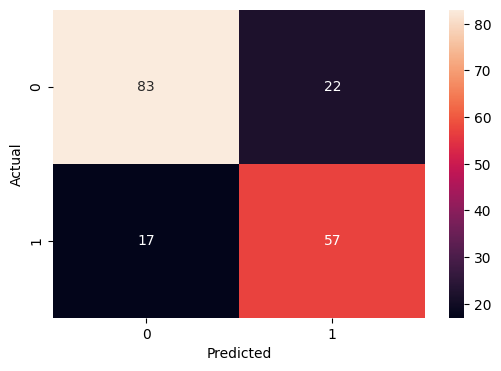

In [37]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Step 26: Classification Report

In [38]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.83      0.79      0.81       105
           1       0.72      0.77      0.75        74

    accuracy                           0.78       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.78      0.78       179



# Step 27: Feature Importance

One of the coolest parts of Decision Trees.

In [39]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

    Feature  Importance
1       Sex    0.310280
5      Fare    0.242798
2       Age    0.217041
0    Pclass    0.111619
3     SibSp    0.056342
4     Parch    0.037738
6  Embarked    0.024181


# Step 28: Visualize Feature Importance

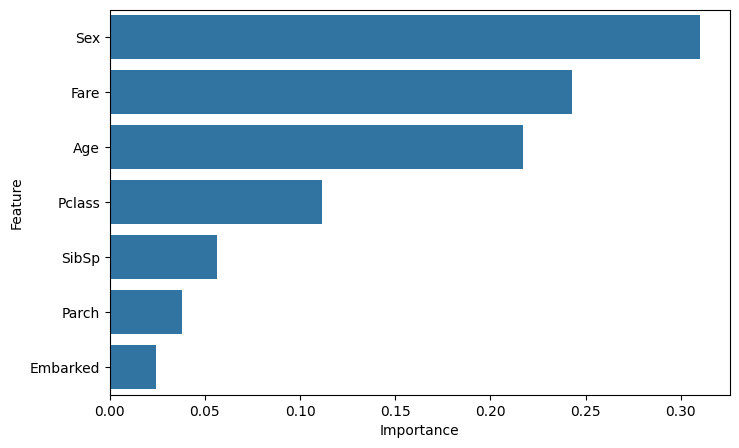

In [40]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.show()

# Step 29: Save Model

In [41]:
import joblib

joblib.dump(
    model,
    "titanic_model.pkl"
)

['titanic_model.pkl']

# Step 30: Predict a New Passenger

Example passenger:

| Feature  | Value      |
| -------- | ---------- |
| Pclass   | 1          |
| Sex      | Female (0) |
| Age      | 25         |
| SibSp    | 0          |
| Parch    | 0          |
| Fare     | 100        |
| Embarked | 2          |


In [43]:
new_passenger = [[
    1,
    0,
    25,
    0,
    0,
    100,
    2
]]

prediction = model.predict(
    new_passenger
)

print(prediction)

[1]


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# **🎓 Concepts Learned in Project 3**

By completing Titanic, you will understand:
- ✅ Real-world datasets
- ✅ Missing values
- ✅ Data cleaning
- ✅ Median / Mode imputation
- ✅ Label Encoding
- ✅ Feature Selection
- ✅ Correlation Analysis
- ✅ Binary Classification
- ✅ Decision Trees
- ✅ Feature Importance
- ✅ Model Evaluation
- ✅ Saving & Loading Models

# After Titanic, the next project should be:
## **🛒 Customer Segmentation using K-Means Clustering**

This will introduce an entirely new ML category:

1. Supervised Learning  ← House Price, Iris, Titanic

2. Unsupervised Learning ← Customer Segmentation

where there are no labels, and the algorithm discovers patterns by itself. This is a major milestone in building a complete ML foundation.